In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from database.db_config import get_engine
import warnings
warnings.filterwarnings("ignore", category=UserWarning)  #removing warning Glyph 10026 for aesthetics  

In [28]:
engine = get_engine()

query_firms = "SELECT company_name, country FROM offers WHERE category = 'IT' AND company_name IS NOT NULL"
df_firms = pd.read_sql_query(query_firms, engine)

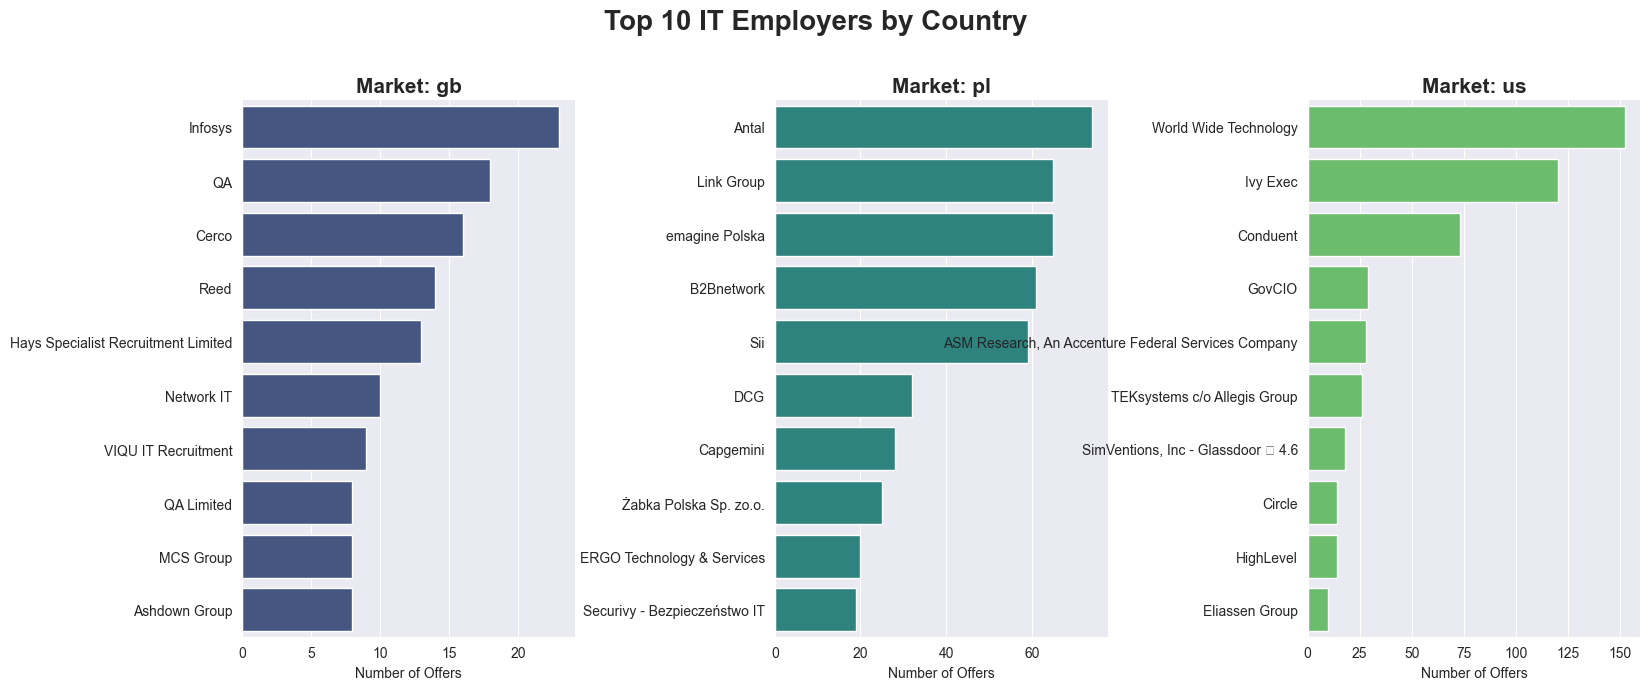

In [29]:
top_firms = df_firms.groupby('country')['company_name'].value_counts().groupby(level=0).head(10).reset_index(name='offer_count')

g = sns.FacetGrid(top_firms, col="country", col_wrap=3, height=7, aspect=0.8, sharey=False, sharex=False, hue="country", palette="viridis")
g.map_dataframe(sns.barplot, y="company_name", x="offer_count")

g.set_titles("Market: {col_name}", size=15, weight='bold')
g.set_axis_labels("Number of Offers", "")
plt.subplots_adjust(top=0.85, wspace=0.6) 
g.fig.suptitle('Top 10 IT Employers by Country', fontsize=20, weight='bold')

plt.show()

## Recruitment and outsourcing firms drive the highest job volumes in all three markets of this dataset. The US leader posts about 6 times more offers than the UK leader. Poland's top 5 firms have nearly identical volumes. 